# Task: Binary Classification

0 → Malignant

1 → Benign

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [ ]:
# Load Breast Cancer dataset
data = load_breast_cancer()

X = data.data        # Features
y = data.target      # Binary labels (0 / 1)

print("Dataset shape:", X.shape)
print("Classes:", data.target_names)


Dataset shape: (569, 30)
Classes: ['malignant' 'benign']


# Dataset facts:

Samples: 569

Features: 30

Classes: Malignant, Benign

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
k = 5
knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')

knn.fit(X_train, y_train)


KNeighborsClassifier(metric='euclidean')

In [ ]:
y_pred = knn.predict(X_test)


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.9590643274853801


In [ ]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=data.target_names))



Classification Report:

              precision    recall  f1-score   support

   malignant       1.00      0.89      0.94        64
      benign       0.94      1.00      0.97       107

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[ 57   7]
 [  0 107]]


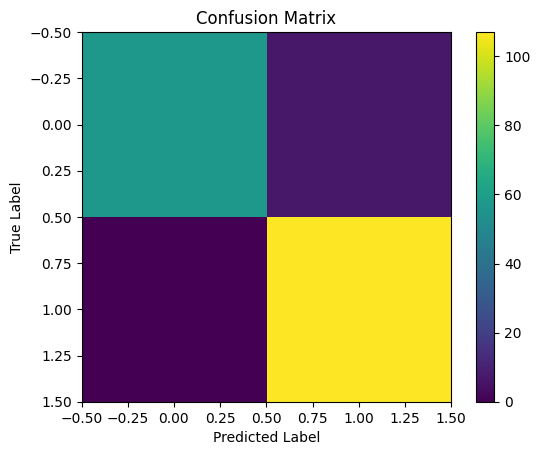

In [ ]:
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
plt.show()


In [ ]:
# New unseen patient data (example)
new_sample = X_test[0].reshape(1, -1)

prediction = knn.predict(new_sample)

print("Predicted Class:", data.target_names[prediction][0])


Predicted Class: malignant
